## Dropout 的影响

让我们亲自看看 dropout 如何实际影响训练。我们将使用 MNIST 数据集和一个简单的卷积网络来进行实验：


In [ ]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


 4349952/11490434 ━━━━━━━━━━━━━━━━━━━━ 3:13 27us/step

我们将定义一个名为 `train` 的函数，该函数将负责整个训练过程，包括以下内容：
* 使用给定的 dropout 率 `d` 定义神经网络架构
* 指定合适的训练参数（优化器和损失函数）
* 执行训练并收集训练历史记录

接下来，我们将针对一系列不同的 dropout 值运行此函数：


In [4]:
def train(d):
    print(f"Training with dropout = {d}")
    model = keras.Sequential([
        keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28,28,1)),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dropout(d),
        keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['acc'])#选择优化器and loss
    hist = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=5,batch_size=64)
    return hist

res = { d : train(d) for d in [0,0.2,0.5,0.8] }

Training with dropout = 0
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - acc: 0.9442 - loss: 0.1908 - val_acc: 0.9761 - val_loss: 0.0751
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - acc: 0.9812 - loss: 0.0614 - val_acc: 0.9847 - val_loss: 0.0477
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - acc: 0.9858 - loss: 0.0459 - val_acc: 0.9880 - val_loss: 0.0356
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - acc: 0.9883 - loss: 0.0366 - val_acc: 0.9875 - val_loss: 0.0365
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - acc: 0.9906 - loss: 0.0300 - val_acc: 0.9893 - val_loss: 0.0321
Training with dropout = 0.2
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - acc: 0.9330 - loss: 0.2212 - val_acc: 0.9795 - val_loss: 0.0635
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - acc: 0.9779 - loss: 0.0716 - val_acc: 0.9855 - val_loss: 0.0428
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - acc: 0.9836 - loss: 0.0535 - val_acc: 0.9869 - val_loss: 0

现在，让我们绘制不同 dropout 值的验证准确率图表，以观察训练速度：


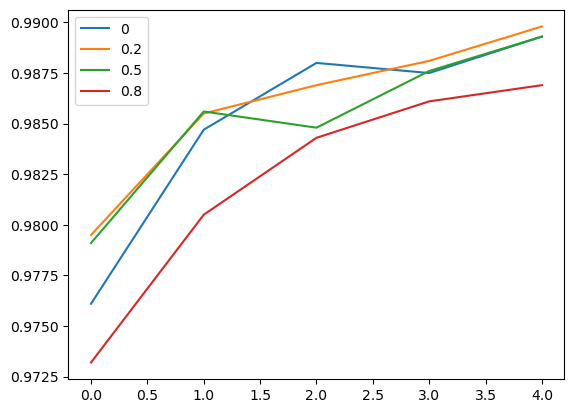

In [5]:
for d,h in res.items():
    plt.plot(h.history['val_acc'],label=str(d))
plt.legend()

从这张图中，你可能会注意到以下几点：
* 当 Dropout 值在 0.2-0.5 范围内时，你会看到训练速度最快，整体效果最好
* 如果没有使用 Dropout ($d=0$)，训练过程可能会变得不太稳定且速度较慢
* 高 Dropout 值（0.8）会使情况变得更糟



---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
